In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import(train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, roc_curve,f1_score,precision_recall_curve,classification_report,confusion_matrix)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
RANDOM_STATE=1


In [3]:
df = pd.read_csv("bank_churn.csv")
df=df.drop(columns=['RowNumber','CustomerId','Surname'])


In [4]:
df['Gender']=LabelEncoder().fit_transform(df['Gender'])
df=pd.get_dummies(df,columns=['Geography'],drop_first=True)

In [5]:
x=df.drop(columns=['Exited'])
y=df['Exited']

print(y.value_counts())

print(x.columns)
print(df.head(10))
df.isnull().sum()

Exited
0    7963
1    2037
Name: count, dtype: int64
Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany',
       'Geography_Spain'],
      dtype='object')
   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   
5          645       1   44       8  113755.78              2          1   
6          822       1   50       7       0.00              2          1   
7          376       0   29       4  115046.74              4          1   
8          501       1   44       4  142051.07             

CreditScore          0
Gender               0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
Geography_Germany    0
Geography_Spain      0
dtype: int64

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=RANDOM_STATE)
scaler=StandardScaler()


In [7]:
x_train_scaled=pd.DataFrame(scaler.fit_transform(x_train),columns=x_train.columns,index=x_train.index)
x_test_scaled=pd.DataFrame(scaler.transform(x_test),columns=x_test.columns,index=x_test.index)


In [8]:
smote= SMOTE(random_state=RANDOM_STATE)
x_train_bal,y_train_bal=smote.fit_resample(x_train_scaled,y_train)


In [9]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
model=XGBClassifier(eval_metric='logloss',random_state=RANDOM_STATE)
cv_scores=cross_val_score(model,x_train_bal,y_train_bal,cv=cv,scoring='roc_auc')

pd.DataFrame({"Fold":range(1,6),"ROC-AUC":cv_scores}).to_csv("cv_scores.csv",index=False)
cv_summary = pd.DataFrame({"Mean ROC-AUC":[cv_scores.mean()],"Std ROC-AUC":[cv_scores.std()]})
cv_summary.to_csv("cv_summary.csv",index=False)

In [10]:
param_dist={"n_estimators":[200,300,400,500],"max_depth":[3,4,5,6],
            "learning_rate":[0.01,0.05,0.1,0.2],"subsample":[0.7,0.8,0.9,1.0],
              "colsample_bytree":[0.7,0.8,0.9,1.0]}
model1=XGBClassifier(eval_metric='logloss',random_state=RANDOM_STATE)
search=RandomizedSearchCV(model1,param_distributions=param_dist,n_iter=25,scoring='roc_auc',cv=cv,
                          random_state=RANDOM_STATE,n_jobs=-1)
search.fit(x_train_bal,y_train_bal)
best_xgb=search.best_estimator_
pd.DataFrame(
    search.best_params_.items(),
    columns=["Hyperparameter", "Best Value"]
).to_csv("best_hyperparameters_draft.csv", index=False)

In [11]:
log_reg=LogisticRegression(max_iter=1000,random_state=RANDOM_STATE)
log_reg.fit(x_train_bal,y_train_bal)
lr_proba=log_reg.predict_proba(x_test_scaled)[:,1]
xgb_proba=best_xgb.predict_proba(x_test_scaled)[:,1]
results_df_draft=pd.DataFrame({'Model':['Logistic Regression', 'XGBoost (tune)'],
                               'Roc-AUC':[roc_auc_score(y_test,lr_proba),roc_auc_score(y_test,xgb_proba)],
                               'F1(default 0.5 threshold)':[f1_score(y_test,(lr_proba>=0.5).astype(int)),f1_score(y_test,(xgb_proba>=0.5).astype(int))]
                              }).round(2)

results_df_draft.to_csv("model_comparison_draft.csv",index=False)                                  

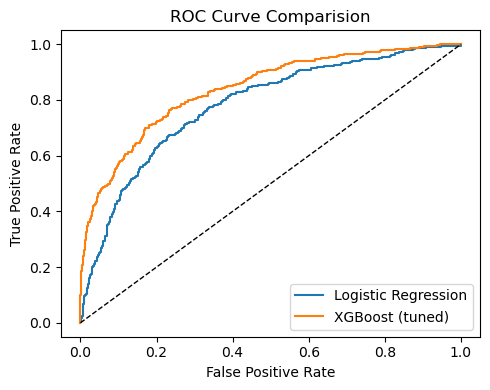

In [12]:
fpr_lr,tpr_lr,_=roc_curve(y_test,lr_proba)
fpr_xgb,tpr_xgb,_=roc_curve(y_test,xgb_proba)
fig,ax=plt.subplots(figsize=(5,4))
ax.plot(fpr_lr,tpr_lr,label='Logistic Regression')
ax.plot(fpr_xgb,tpr_xgb,label='XGBoost (tuned)')
ax.plot([0,1],[0,1],"k--",linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparision")
ax.legend()
plt.tight_layout()
plt.savefig("roc_curve.png",dpi=120)
plt.show()

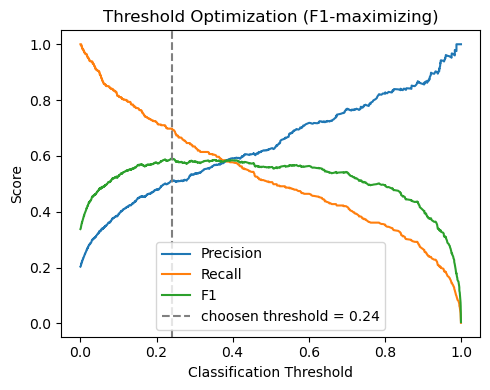

In [13]:
precisions,recalls,thresholds=precision_recall_curve(y_test,xgb_proba)
f1_score=2*(precisions*recalls)/(precisions+recalls+1e-9)
best_index=np.argmax(f1_score[:-1])
optimal_threshold=thresholds[best_index]

y_pred_optimal=(xgb_proba>=optimal_threshold).astype(int)
pd.DataFrame({"Optimal Threshold":[optimal_threshold]}).to_csv("Optimal_Threshold.csv",index=False)
optimal_report = classification_report(y_test,y_pred_optimal,output_dict=True)
pd.DataFrame(optimal_report).transpose().round(3).to_csv("optimal_threshold_report.csv")

cm=confusion_matrix(y_test,y_pred_optimal)
pd.DataFrame(cm, index=["Actual: Stayed","Actual:Churned"],
             columns=['Predicted:stayed','Predicted:Churned']).to_csv("confusion matrix.csv")
fig,ax=plt.subplots(figsize=(5,4))
ax.plot(thresholds,precisions[:-1],label="Precision")
ax.plot(thresholds, recalls[:-1], label="Recall")
ax.plot(thresholds, f1_score[:-1], label="F1")
ax.axvline(optimal_threshold,color='gray', linestyle='--',label=f'choosen threshold = {optimal_threshold:.2f}')
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Optimization (F1-maximizing)")
ax.legend()
plt.tight_layout()
plt.savefig("threshold_optimization.png", dpi=120)
plt.show

y_pred_default=(xgb_proba>0.5).astype(int)
default_report = classification_report(
    y_test,
    y_pred_default,
    output_dict=True
)

pd.DataFrame(default_report).transpose().round(3).to_csv(
    "default_threshold_report.csv"
)
default_cm=confusion_matrix(y_test,y_pred_default)
pd.DataFrame(
    default_cm,
    index=["Actual: Stayed", "Actual: Churned"],
    columns=["Predicted: Stayed", "Predicted: Churned"]
).to_csv("default_confusion_matrix.csv")


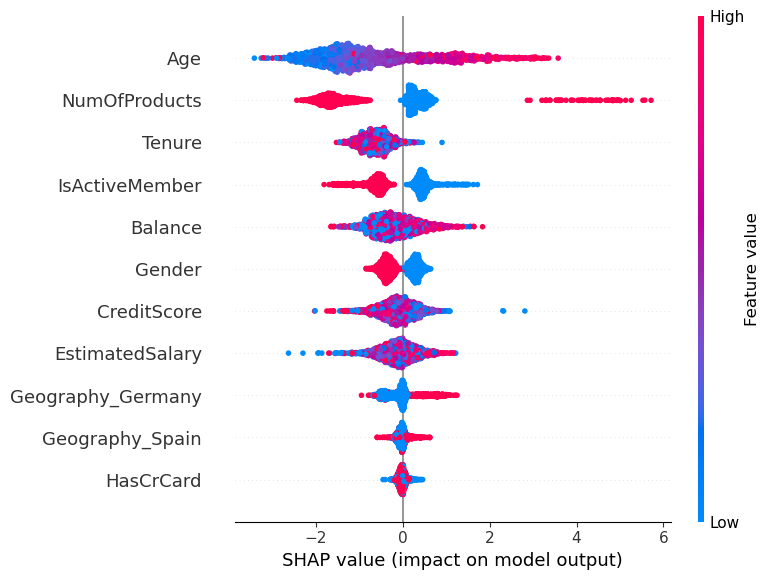

In [14]:
explainer = shap.TreeExplainer(best_xgb)
shap_values=explainer.shap_values(x_test_scaled)

fig= plt.figure(figsize=(7,5))
shap.summary_plot(shap_values,x_test_scaled,show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

mean_abs_shap= pd.Series(np.abs(shap_values).mean(axis=0),index=x_test_scaled.columns, name="Mean | SHAP value|").sort_values(ascending=False)
mean_abs_shap.to_csv("Shap_Feature_Ranking.csv")

In [17]:
risk_df=x_test.copy()
risk_df['churn_probability']=xgb_proba
risk_df['flagged_for_outreach']=y_pred_optimal
risk_df['expected_value_at_risk']=risk_df['churn_probability']*risk_df["Balance"]

risk_df=risk_df.sort_values("expected_value_at_risk",ascending=False)
risk_df.head(20)[["Balance", "churn_probability", 
         "flagged_for_outreach",
         "expected_value_at_risk"]].to_csv("top20_customers_at_risk.csv", index=False
)
